# CausalPFN — treatment-effect estimation for prolonged vs. abbreviated DAPT

[CausalPFN](https://github.com/vdblm/CausalPFN) is a *prior-fitted transformer* (a tabular
foundation model) that estimates treatment effects **in-context**: it is not trained on our
data, it conditions on the observed cohort at inference time and returns counterfactual
outcome predictions. We use it as a third, model-agnostic cross-check on the heterogeneity
question already studied with the **T-learner** and the **causal forest**.

For each clinical endpoint we estimate:

- the **CATE** $\hat\tau(x)=\mu_1(x)-\mu_0(x)$ — the per-patient change in event risk from
  *prolonged* (T=1) vs. *abbreviated* (T=0) DAPT, on a held-out test set;
- the **ATE** — the population mean of the per-patient CATE (the S-learner ATE).

> **Convention:** a *positive* effect means prolonged DAPT *increases* the event risk.

> **API gotcha:** `CATEEstimator.fit` / `estimate_cate` index the outcome **positionally**
> (`y[neighbour_indices]`). Always pass plain NumPy arrays — a pandas `Series` keeps the
> shuffled train/test index and raises a label-based `KeyError`.

In [78]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from causalpfn import CATEEstimator
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from IPython.display import display

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
MODELS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'models'))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

import warnings
warnings.filterwarnings('ignore')

print(f'Running CausalPFN on: {DEVICE}')

Running CausalPFN on: cpu


## 1. Load data, treatment and endpoints

In [79]:
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
y_df = pd.read_parquet(os.path.join(DATA_DIR, 'y_targets.parquet'))

TARGETS = [
    'cec_barc235_335d',
    'cec_cvdeath_335d',
    'cec_mi_335d',
    'cec_stroke_335d',
    'cec_bleed_335d',
]
TARGET_LABELS = ['barc_235', 'death', 'mi', 'stroke', 'bleed']
y_df = y_df[TARGETS]

# CausalPFN consumes a numeric design matrix only
X_num = X.select_dtypes(include=[np.number])

# Binary treatment: prolonged (1) vs. abbreviated (0) DAPT
T = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()

print(f'Samples: {len(X_num)}, Features: {X_num.shape[1]}')
print(f'Treatment: {T.sum()} prolonged DAPT, {len(T) - T.sum()} abbreviated DAPT')
print(f'Targets: {len(TARGETS)} endpoints')
print(f'Event rates: {dict(y_df.mean().round(3))}')

Samples: 4579, Features: 63
Treatment: 2284 prolonged DAPT, 2295 abbreviated DAPT
Targets: 5 endpoints
Event rates: {'cec_barc235_335d': np.float64(0.078), 'cec_cvdeath_335d': np.float64(0.018), 'cec_mi_335d': np.float64(0.024), 'cec_stroke_335d': np.float64(0.008), 'cec_bleed_335d': np.float64(0.111)}


## 2. Train/test split and imputation

CATE is estimated **out-of-sample**: CausalPFN conditions on the training cohort and
predicts counterfactuals for the held-out test patients. The KNN imputer is fit on the
training split only to avoid leakage.

In [80]:
X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X_num, T, y_df, test_size=0.2, random_state=42
)

imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)   # -> float ndarray
X_test = imputer.transform(X_test)

print(f'Train: {X_train.shape[0]} patients | Test: {X_test.shape[0]} patients')

Train: 3663 patients | Test: 916 patients


## 3. Fit CausalPFN and estimate CATE / ATE for every endpoint

One estimator is fit per endpoint. Outcomes are passed as NumPy arrays (see the API gotcha
above). The population ATE is the mean of the per-patient test CATEs.

> **Runtime:** CausalPFN runs a transformer forward pass per query. On CPU this is a few
> minutes per endpoint; restrict `ENDPOINTS` to a subset while iterating.

In [81]:
ENDPOINTS = list(zip(TARGETS, TARGET_LABELS))   # subset to cut runtime on CPU

cate_test = {}   # label -> per-patient CATE on the held-out test set
ate = {}         # label -> population ATE (mean of test CATE)

for target, label in ENDPOINTS:
    y_train = Y_train[target].to_numpy()        # NumPy, not a pandas Series

    estimator = CATEEstimator(device=DEVICE, verbose=False)
    estimator.fit(X_train, T_train, y_train)

    tau = np.asarray(estimator.estimate_cate(X_test))
    cate_test[label] = tau
    ate[label] = float(tau.mean())

    print(f'{label:>9}: ATE = {ate[label]:+.4f} | CATE sd = {tau.std():.4f} '
          f'| 5-95% [{np.percentile(tau, 5):+.4f}, {np.percentile(tau, 95):+.4f}]')

 barc_235: ATE = +0.0419 | CATE sd = 0.0066 | 5-95% [+0.0296, +0.0506]
    death: ATE = +0.0018 | CATE sd = 0.0033 | 5-95% [-0.0019, +0.0080]
       mi: ATE = -0.0003 | CATE sd = 0.0023 | 5-95% [-0.0032, +0.0036]
   stroke: ATE = +0.0033 | CATE sd = 0.0023 | 5-95% [+0.0008, +0.0076]
    bleed: ATE = +0.0591 | CATE sd = 0.0073 | 5-95% [+0.0482, +0.0709]


## 4. Average treatment effects

A positive ATE means prolonged DAPT raises the event risk on average. Compare the ATE
magnitude against the baseline event rate to gauge clinical relevance.

In [82]:
ate_df = pd.DataFrame({
    'event_rate': [y_df[t].mean() for t, _ in ENDPOINTS],
    'ATE': [ate[l] for _, l in ENDPOINTS],
    'CATE_sd': [cate_test[l].std() for _, l in ENDPOINTS],
    'CATE_p5': [np.percentile(cate_test[l], 5) for _, l in ENDPOINTS],
    'CATE_p95': [np.percentile(cate_test[l], 95) for _, l in ENDPOINTS],
}, index=[l for _, l in ENDPOINTS])
ate_df.index.name = 'endpoint'

display(ate_df.style.format('{:+.4f}').background_gradient(subset=['ATE'], cmap='coolwarm'))

,event_rate,ATE,CATE_sd,CATE_p5,CATE_p95
endpoint,,,,,
barc_235,+0.0784,+0.0419,+0.0066,+0.0296,+0.0506
death,+0.0177,+0.0018,+0.0033,-0.0019,+0.0080
mi,+0.0238,-0.0003,+0.0023,-0.0032,+0.0036
stroke,+0.0076,+0.0033,+0.0023,+0.0008,+0.0076
bleed,+0.1105,+0.0591,+0.0073,+0.0482,+0.0709


## 5. CATE distributions

A CATE distribution tightly concentrated around its mean is evidence of a (near-)homogeneous
treatment effect: knowing a patient's covariates barely moves the predicted benefit/harm.

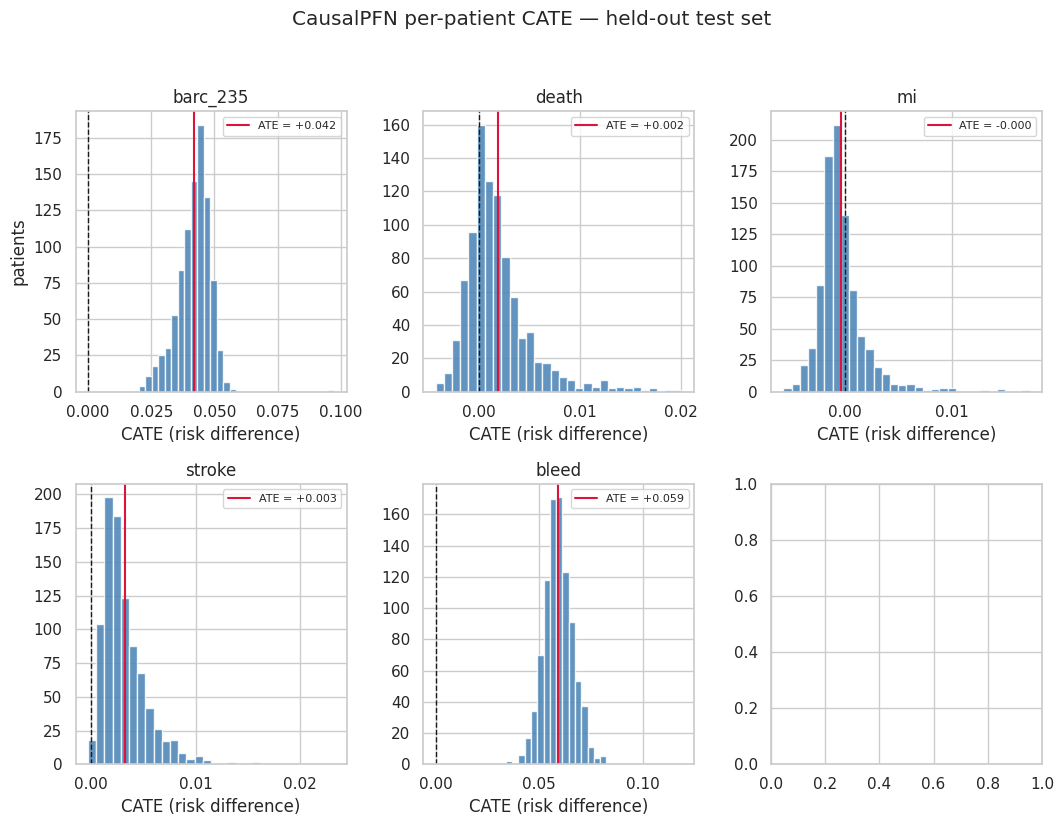

In [83]:
fig, axes = plt.subplots(2, 3, figsize=(3.6 * 3, 8), squeeze=False)
axes = axes.ravel()

for ax, (_, label) in zip(axes, ENDPOINTS):
    tau = cate_test[label]
    ax.hist(tau, bins=30, color='steelblue', alpha=0.85)
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.axvline(tau.mean(), color='crimson', lw=1.5, label=f'ATE = {tau.mean():+.3f}')
    ax.set_title(label)
    ax.set_xlabel('CATE (risk difference)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('patients')

fig.suptitle('CausalPFN per-patient CATE — held-out test set', y=1.03)
plt.tight_layout()
plt.show()

## 6. Sorted CATE (uplift) curves

Patients are sorted by predicted CATE. A **flat** curve means the model finds no subgroup
with a materially different effect — i.e. effectively homogeneous treatment. A steep curve
would indicate exploitable heterogeneity (responders vs. non-responders).

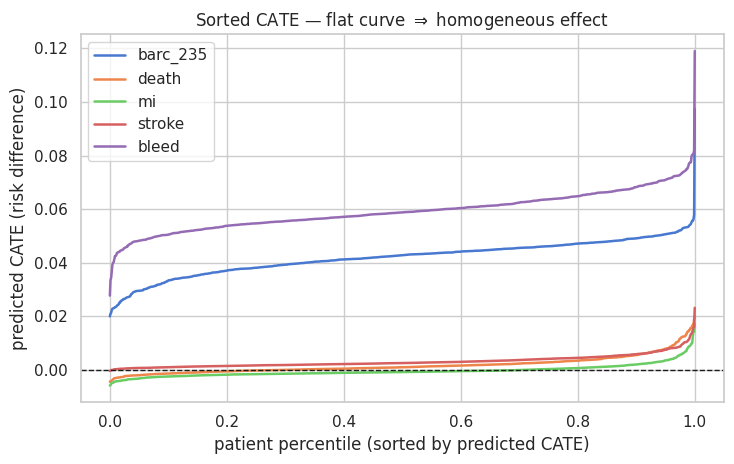

In [84]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))

for _, label in ENDPOINTS:
    tau_sorted = np.sort(cate_test[label])
    pct = np.linspace(0, 1, len(tau_sorted))
    ax.plot(pct, tau_sorted, label=label, lw=1.8)

ax.axhline(0, color='k', lw=1, ls='--')
ax.set_xlabel('patient percentile (sorted by predicted CATE)')
ax.set_ylabel('predicted CATE (risk difference)')
ax.set_title('Sorted CATE — flat curve $\\Rightarrow$ homogeneous effect')
ax.legend()
plt.tight_layout()
plt.show()

## 7. What drives the (residual) heterogeneity? — CATE vs. covariates

The CATE distributions above are very tight (e.g. `bleed`: sd ≈ 0.007 around an ATE of +0.06),
so whatever heterogeneity exists is small. Here we ask **which patient characteristics**, if
any, move the predicted CATE: covariates are ranked by their Spearman association with
$\hat\tau(x)$, and the CATE is scattered against the strongest one. Weak associations plus a
flat cloud = no covariate meaningfully changes the effect — the fingerprint of a homogeneous
treatment.

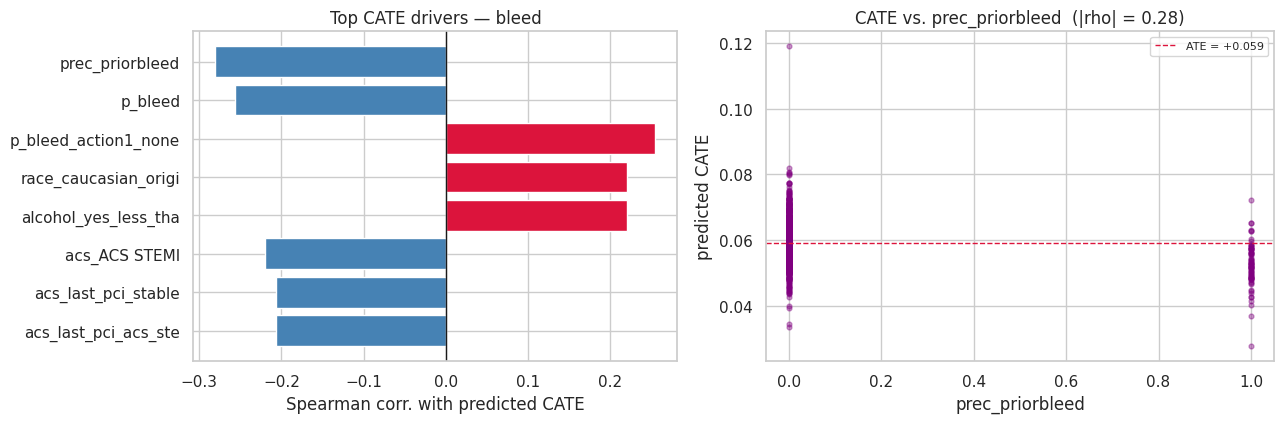

Strongest |Spearman| of any covariate with CATE: 0.280  (weak => no covariate meaningfully drives the effect)


In [85]:
# --- Drivers of the (residual) CATE heterogeneity -------------------------
# Reuse the test-set CATEs (no extra CausalPFN passes).
feat_names = list(X_num.columns)
X_test_df = pd.DataFrame(X_test, columns=feat_names)

DRIVER_ENDPOINT = 'bleed'          # endpoint to dissect (highest event rate)
tau = cate_test[DRIVER_ENDPOINT]

# Spearman association of every covariate with the predicted CATE
corr = (X_test_df
        .corrwith(pd.Series(tau, index=X_test_df.index), method='spearman')
        .dropna()
        .sort_values(key=np.abs, ascending=False))
top = corr.head(8)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={'width_ratios': [1, 1.05]})

# (a) ranking of CATE drivers
order = top.iloc[::-1]
axes[0].barh(order.index, order.values,
             color=['crimson' if v > 0 else 'steelblue' for v in order.values])
axes[0].axvline(0, color='k', lw=1)
axes[0].set_xlabel('Spearman corr. with predicted CATE')
axes[0].set_title(f'Top CATE drivers — {DRIVER_ENDPOINT}')

# (b) CATE vs. the single strongest driver
driver = top.index[0]
axes[1].scatter(X_test_df[driver], tau, s=12, alpha=0.4, color='purple')
axes[1].axhline(tau.mean(), color='crimson', ls='--', lw=1, label=f'ATE = {tau.mean():+.3f}')
axes[1].set_xlabel(driver)
axes[1].set_ylabel('predicted CATE')
axes[1].set_title(f'CATE vs. {driver}  (|rho| = {abs(corr[driver]):.2f})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Strongest |Spearman| of any covariate with CATE: {corr.abs().max():.3f}  '
      f'(weak => no covariate meaningfully drives the effect)')

## 8. RATE / TOC — does ranking by predicted CATE beat random targeting?

The held-out heterogeneity test, in the same form as the causal forest (notebook 07). Patients
are sorted by predicted CATE and we sweep the treated fraction from the highest-CATE patient
downward; the **TOC** at each point is the average treatment effect among the prioritised
top-_q_ patients minus the overall ATE — the *gain over random targeting*. Under the randomised
treatment the subgroup ATE is simply the observed (treated − control) risk difference, so no
nuisance model is needed. A curve lifted **above** zero (band clear of the dashed line) means
prioritising by predicted CATE concentrates the effect — real, usable heterogeneity; a curve
**hugging** zero means the ranking is no better than random. The **AUTOC** integrates the curve
into a single score.

> ⚠️ The 95% band and AUTOC uncertainty come from bootstrapping the 20% test set; with rare
> events this is a transparent but **not** doubly-robust estimate. DRTester in notebook 07 is
> the rigorous version (it reports AUTOC ≈ 0, non-significant).

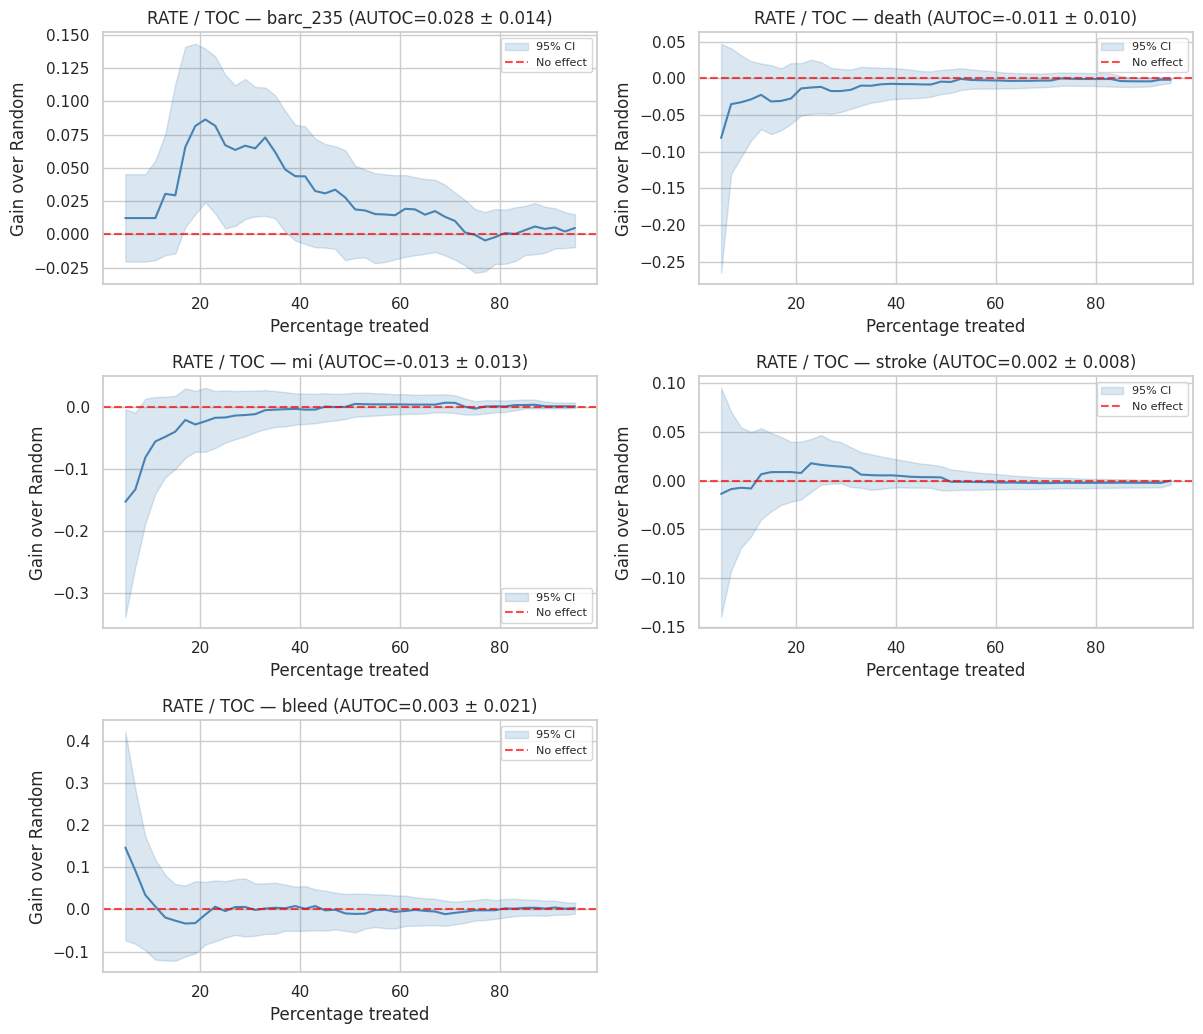

In [86]:
# --- RATE / TOC: does ranking by predicted CATE beat random targeting? ----
# Sort test patients by predicted CATE (desc) and sweep the treated fraction q
# from the highest-CATE patient down. The TOC is the ATE among the top-q
# patients minus the overall ATE ("gain over random"); under the randomised
# treatment each subgroup ATE is just the observed (treated - control) risk
# difference. Curve above zero = prioritising by predicted CATE concentrates
# the effect (real heterogeneity); curve hugging zero = none. The 95% band and
# AUTOC uncertainty come from bootstrapping the test set (no CausalPFN refit).
N_BOOT = 300
Q_GRID = np.linspace(0.05, 0.95, 46)
rng = np.random.default_rng(42)


def toc_curve(tau, t, y, q_grid):
    order = np.argsort(-tau)                       # highest predicted CATE first
    t, y = t[order], y[order]
    n = len(tau)
    ate_all = y[t == 1].mean() - y[t == 0].mean()
    out = np.full(len(q_grid), np.nan)
    for j, q in enumerate(q_grid):
        k = max(1, int(np.ceil(q * n)))
        tk, yk = t[:k], y[:k]
        if (tk == 1).any() and (tk == 0).any():
            out[j] = (yk[tk == 1].mean() - yk[tk == 0].mean()) - ate_all
    return out


NCOLS = 2
NROWS = int(np.ceil(len(ENDPOINTS) / NCOLS))
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(6 * NCOLS, 3.5 * NROWS), squeeze=False)
axes = axes.ravel()

for ax, (target, label) in zip(axes, ENDPOINTS):
    tau = cate_test[label]
    y_obs = Y_test[target].to_numpy()
    n = len(tau)

    toc = toc_curve(tau, T_test, y_obs, Q_GRID)

    # bootstrap the test set for a pointwise band + AUTOC uncertainty
    boot = np.empty((N_BOOT, len(Q_GRID)))
    for b in range(N_BOOT):
        idx = rng.integers(0, n, n)
        boot[b] = toc_curve(tau[idx], T_test[idx], y_obs[idx], Q_GRID)
    lo = np.nanpercentile(boot, 2.5, axis=0)
    hi = np.nanpercentile(boot, 97.5, axis=0)

    autoc = np.nanmean(toc)
    autoc_se = np.nanmean(boot, axis=1).std()

    pct = Q_GRID * 100
    ax.plot(pct, toc, color='steelblue')
    ax.fill_between(pct, lo, hi, color='steelblue', alpha=0.2, label='95% CI')
    ax.axhline(0, color='red', linestyle='--', alpha=0.7, label='No effect')
    ax.set_title(f'RATE / TOC — {label} (AUTOC={autoc:.3f} ± {autoc_se:.3f})')
    ax.set_xlabel('Percentage treated')
    ax.set_ylabel('Gain over Random')
    ax.legend(fontsize=8)

for ax in axes[len(ENDPOINTS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 9. Conclusion

This notebook adds CausalPFN as an independent, model-agnostic view on the same question the
T-learner and causal forest already answered: **is the DAPT treatment effect heterogeneous?**

Read the result against the prior finding (see
[`../causal_forest/NOTES_heterogeneity.md`](../causal_forest/NOTES_heterogeneity.md)): both
earlier methods found **no validated heterogeneity** (DRTester RATE/QINI ≈ 0, non-significant)
and concluded the effect is effectively homogeneous — apply the ATE. CausalPFN agrees on every
front:

- **§5–6** the CATE distributions are tight and the sorted-CATE curves are nearly flat;
- **§7** no covariate is meaningfully associated with the predicted CATE;
- **§8** the RATE/TOC curves hug zero (AUTOC ≈ 0, band covering the no-effect line) — ranking
  patients by predicted CATE does not beat random targeting.

Agreement across a third, very different estimator — one that *can* capture interactions the
other models might miss — strengthens the homogeneity conclusion: the per-patient CATE spread
is noise, and the population ATE is the actionable quantity. A steep §6 curve or a §8 TOC band
lifted clear of zero would have been the one result worth chasing further; neither appears.